# Compare Forward Results between Loop 0 and Loop 1. 

## Prepare the Notebook.

### Import the Libraries.

In [ ]:
import os
import sys
import yaml

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns
import scanpy as sc
from scipy.stats import gaussian_kde
from scipy.spatial.distance import cdist
from sklearn.preprocessing import LabelEncoder
import torch
from tqdm import tqdm

from sc_exp_design.metrics import compute_e_distance
from sc_exp_design.models import FlowMatching, TargetPredictionModel

sys.path.insert(0, "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/shared_utils")
from experiment_utils import (
    get_shuffled_populations,
    create_dir,
    get_unique_conds
)
from data_utils import (
    annotate_perturbations,
    get_protocol_tranformations,
)

### Constants and paths.

In [2]:
# ---- Shared paths ---- 
h5ad_path_loop1_500k = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/new_dataset/BloodPlus_celltype_pm_500k_filtered_.h5ad"
h5ad_path_loop0_concat = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/new_dataset/BloodPlus_Logicle_pm_old_experiments_.h5ad"

annotation_config_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/forward/conditional_model/flow_matching/config/annotation/bloodplus.yaml"

# ---- Loop 0 paths ----
simulation_data_dir_loop0 = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/forward/flow_matching/requested_protocols/2026-06-05_01-27-40_0271365f"
simulation_conf_path_loop0 = os.path.join(simulation_data_dir_loop0, "config.yaml")

# ---- Loop 1 paths ----
simulation_data_dir_loop1 = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/forward/flow_matching/requested_protocols/2026-06-05_01-34-27_ce50ae36"
simulation_conf_path_loop1 = os.path.join(simulation_data_dir_loop1, "config.yaml")


### Read Configurations and Prepare Paths.

In [3]:
# ---- Loop 0 ----
with open(simulation_conf_path_loop0, "r") as fb:
    simulation_conf_dict_loop0 = yaml.safe_load(fb)

path_config_dict_loop0 = simulation_conf_dict_loop0["paths"]
metadata_csv_path_loop0 = path_config_dict_loop0["condition_metadata_path"]
model_path_loop0 = path_config_dict_loop0["perturbation_prediction_path"]
classifier_path_loop0 = path_config_dict_loop0["ct_classifier_path"]
dump_dir_loop0 = os.path.join(simulation_data_dir_loop0, "plots")
results_path_loop0 = os.path.join(simulation_data_dir_loop0, "fwd_results.npz")

# ---- Loop 1 ----
with open(simulation_conf_path_loop1, "r") as fb:
    simulation_conf_dict_loop1 = yaml.safe_load(fb)

path_config_dict_loop1 = simulation_conf_dict_loop1["paths"]
metadata_csv_path_loop1 = path_config_dict_loop1["condition_metadata_path"]
model_path_loop1 = path_config_dict_loop1["perturbation_prediction_path"]
classifier_path_loop1 = path_config_dict_loop1["ct_classifier_path"]
dump_dir_loop1 = os.path.join(simulation_data_dir_loop1, "plots")
results_path_loop1 = os.path.join(simulation_data_dir_loop1, "fwd_results.npz")


### Read Annotation Configuration.

In [4]:
# ---- Read annotation yaml ----
with open(annotation_config_path, "r") as fb:
    ann_config = yaml.safe_load(fb)
protocol_cols = ann_config["protocol_columns"]

### Color palette.

In [5]:
# Your color_map (remove duplicate key if necessary – keep the first or second as you prefer)
color_map = {
    'HSCs': '#003049',
    'earlyMPP': '#023e8a',
    'MPP': '#005f73',
    'GMP-Neutro': '#0a9396',
    'GMP_cycling': '#1d3557',
    'MPP_MgkEry': '#264653',
    'MgKEryPro1': '#7f908f',
    'MgKEryPro2': '#4a5c6a',
    'late_MgkPro': '#3a4f6a',      # key appears twice – keep only one
    'EosBasMast1': '#6c757d',
    'EosBasMast2': '#780000',
    'EosBasMast3': '#9d0910',
    'EryPro': '#af0e18',
    'MLP': '#c1121f',
    'LMPP-CLP': '#ae2012',
    'preProB': '#9b2226',
    'ProB': '#df817a',
    'pre_cDC1': '#e76f51',
    'pre_cDC2': '#f4a261',
    'Early_GMP': '#ee9b00',
    'CD14Mono': '#fdf0d5',
    'CD16Mono': '#e9d8a6',
    'CyclingPro1': '#669bbc',
    'CyclingPro2': '#8ecae6',
}

## Load stuff.

### Load Models.

In [13]:
# ---- Loop 0 models ----
cfm_loop0 = FlowMatching.load(model_path_loop0)
classifier_loop0 = TargetPredictionModel.load(classifier_path_loop0)

# ---- Loop 1 models ----
cfm_loop1 = FlowMatching.load(model_path_loop1)
classifier_loop1 = TargetPredictionModel.load(classifier_path_loop1)

### Read data and get unique conditions.

In [6]:
# ---- Get full data from loop 0 and unique conditions ----
adata_loop0_concat = sc.read_h5ad(h5ad_path_loop0_concat)
X_cond_loop0 = get_unique_conds(adata_loop0_concat, protocol_cols)
X_cond_loop0_log1p = np.log1p(X_cond_loop0)

### Read annotated subset.

In [7]:
# ---- Get 500k subset from loop 1 and unique conditions ----
adata_loop1_500k = sc.read_h5ad(h5ad_path_loop1_500k)
le_ct = LabelEncoder().fit(adata_loop1_500k.obs["cell_type"])
adata_loop1_500k

AnnData object with n_obs × n_vars = 471836 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'leiden', 'leiden_sub', 'leiden_old', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'leiden_colors_old',

### Read metadata.

In [8]:
# ---- Read metadata excel ----
metadata_df = pd.read_excel(metadata_csv_path_loop1)
metadata_df.columns = [c.replace("/", "_") for c in metadata_df.columns]
metadata_df = metadata_df.loc[
    metadata_df["experiment_id"] == "LPHO012",
    protocol_cols + ["experiment_number", "experiment_id"]
]
metadata_df

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,experiment_number,experiment_id
262,10,2.5,750,560.0,0.0,10,0,0,0,0.0,20,14,205,LPHO012
263,10,2.5,375,560.0,0.0,10,0,0,0,0.0,20,14,206,LPHO012
264,10,2.5,75,560.0,0.0,10,0,0,0,0.0,20,14,207,LPHO012
265,10,2.5,0,560.0,0.0,10,0,0,0,0.0,20,14,208,LPHO012
266,0,2.5,0,560.0,0.0,10,0,0,0,0.0,20,14,209,LPHO012
267,0,0.0,0,70.0,0.0,0,100,0,0,0.0,20,14,210,LPHO012


### Get condition values for LPHO012.

In [9]:
# ---- Get LPHO012 condition ----
X_cond_lpho012 = metadata_df[protocol_cols].astype(float).values
X_cond_lpho012_log1p = np.log1p(X_cond_lpho012)
X_cond_lpho012_log1p.shape

(6, 12)

### Read simulated data.

In [10]:
# ---- Loop 0 sim data ----
sim_data_loop0 = np.load(results_path_loop0)
for k, v in sim_data_loop0.items():
    print(k, v.shape)

# ---- Loop 1 sim data ----
sim_data_loop1 = np.load(results_path_loop1)
for k, v in sim_data_loop1.items():
    print(k, v.shape)

X (20000, 6, 26)
X_channel (20000, 6, 20)
X_scatter (20000, 6, 6)
ct_logits (20000, 6, 24)
ct_probs (20000, 6, 24)
X (20000, 6, 26)
X_channel (20000, 6, 20)
X_scatter (20000, 6, 6)
ct_logits (20000, 6, 24)
ct_probs (20000, 6, 24)


## Tranform data.

### Annotate Condition data.

In [11]:
# ---- Get protocol transformations ----
column2tranform = get_protocol_tranformations(
    protocol_cols,
    log1p_exp_cols=ann_config["log1p_exp_cols"],
    log21p_exp_cols=ann_config["log21p_exp_cols"],
    inverse=False,
)

# ---- Loop 0 concatenated data ----
adata_loop0_concat = annotate_perturbations(
    adata_loop0_concat,
    protocol_cols,
    protocol_obs_key_added=ann_config["protocol_obs_key_added"],
    protocol_sep=ann_config["protocol_sep"],
    one_hot_uns_key_added=ann_config["one_hot_uns_key_added"],
    column2tranform=column2tranform,
)

# ---- Loop 1 500k subset ----
adata_loop1_500k = annotate_perturbations(
    adata_loop1_500k,
    protocol_cols,
    protocol_obs_key_added=ann_config["protocol_obs_key_added"],
    protocol_sep=ann_config["protocol_sep"],
    one_hot_uns_key_added=ann_config["one_hot_uns_key_added"],
    column2tranform=column2tranform,
)

100%|██████████| 12/12 [00:00<00:00, 219.46it/s]


### Renormalizing data.

In [15]:
# ---- Function to Standardize data ----
def standardize_adatas(
    adata_class, adata_ref
):
    # get parameters from classifiers adata
    X_channel_params_class = adata_class.uns["X_channel_params"]
    X_scatter_params_class = adata_class.uns["X_scatter_params"]

    # get parameters from cellular response prediction adata
    X_channel_params_ref = adata_ref.uns["X_channel_params"]
    X_scatter_params_ref = adata_ref.uns["X_scatter_params"]

    # get standardized m from classifier data
    X_channel_standardized_classifier = adata_class.obsm["X_channel_standardized"]
    X_scatter_standardized_classifier = adata_class.obsm["X_scatter_standardized"]

    # inverse standardization on classifier data
    X_channel_classifier = X_channel_standardized_classifier*X_channel_params_class["std"] + X_channel_params_class["mean"]
    X_scatter_classifier = X_scatter_standardized_classifier*X_scatter_params_class["std"] + X_scatter_params_class["mean"]

    # transformation with forward model stanardization parameters
    X_channel_classifier_renormalized = (X_channel_classifier - X_channel_params_ref["mean"])/X_channel_params_ref["std"]
    X_scatter_classifier_renormalized = (X_scatter_classifier - X_scatter_params_ref["mean"])/X_scatter_params_ref["std"]

    # store re-transformed features
    adata_class.obsm["X_channel_renormalized"] = X_channel_classifier_renormalized
    adata_class.obsm["X_scatter_renormalized"] = X_scatter_classifier_renormalized
    return adata_class

# # ---- Get adatas Loop 0 ----
adata_class_loop0 = classifier_loop0.train_data.adata
adata_ref_loop0 = cfm_loop0.train_data.adata
adata_class_loop0 = standardize_adatas(adata_class_loop0, adata_ref_loop0)

# ---- Get adatas Loop 1 ----
adata_class_loop1 = classifier_loop1.train_data.adata
adata_ref_loop1 = cfm_loop1.train_data.adata
adata_class_loop1 = standardize_adatas(adata_class_loop1, adata_ref_loop1)

### Filter adata for target experiments.

In [16]:
lph012_exp_numbers = metadata_df["experiment_number"].to_list()
adata_real_lpho012_mask = adata_class_loop1.obs["experiment_number"].astype(int).map(
    lambda e: e in lph012_exp_numbers
)
n_cells_lpho012 = adata_real_lpho012_mask.sum()
adata_lph012 = adata_class_loop1[adata_real_lpho012_mask]
print(f"{n_cells_lpho012=}\n{adata_lph012=}")


n_cells_lpho012=np.int64(15792)
adata_lph012=View of AnnData object with n_obs × n_vars = 15792 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'leiden', 'leiden_sub', 'leiden_old', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'cell_type_colo

## Plot Marker features mean per experiment.

### Stack predictions per experiment in a single array.

In [ ]:

X_loop0 = get_shuffled_populations(X_gen_loop0, n_pops=n_pops, n_iters=n_iters)
X_loop0.shape

(100, 10, 12000, 26)

In [ ]:

# ---- Loop 0 ----
X_gen_loop0 = sim_data_loop0["X"]
X_scatter_gen_loop0 = sim_data_loop0["X_scatter"]
X_channel_gen_loop0 = sim_data_loop0["X_channel"]
X_loop0 = get_shuffled_populations()
print(f"{X_gen_loop0.shape=}")

# ---- Loop 1 ----
X_gen_loop1 = sim_data_loop1["X"]
X_scatter_gen_loop1 = sim_data_loop1["X_scatter"]
X_channel_gen_loop1 = sim_data_loop1["X_channel"]
print(f"{X_gen_loop1.shape=}")

X_gen_loop0.shape=(20000, 6, 26)
X_gen_loop1.shape=(20000, 6, 26)


### Compute mean and store it.

In [21]:
adata_lph012

View of AnnData object with n_obs × n_vars = 15792 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'leiden', 'leiden_sub', 'leiden_old', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'leiden_color

In [ ]:
# ---- Define bootstrap settings ----
n_pops = 100

# ---- Define names and keys ----
state_key = 'X_channel_standardized+X_scatter_standardized'
col_names = adata_class_loop1.var_names.to_list() + ann_config["scatter_columns"]

# ---- Store for data frames ----
stats_df_dict = {}

# ---- Iterate over the experiments ----
for idx, (exp_number, exp_idx) in enumerate(adata_lph012.obs.groupby("experiment_number").groups.items()):
    # ---- Retrieve real adata ----
    adata_exp = adata_lph012[exp_idx]
    x_real_exp = adata_exp.obsm[state_key]

    # ---- Compute statistics from real data ----
    mean_x_real_exp = x_real_exp.mean(0)
    std_x_real_exp = x_real_exp.std(0)

    # ---- Retrieve generated cellular states for current experiment ----
    x_gen_exp_loop0 = X_gen_loop0[:, idx, :] # n_cells x n_feats
    x_gen_exp_loop1 = X_gen_loop1[:, idx, :] # n_cells x n_feats

    # ---- Prepare populations for bootstrapping ----
    x_pop_loop0 = get_shuffled_populations(x_gen_exp_loop0, n_pops=n_pops, n_iters=1)[0] # 1 x n_pops x n_cells x n_feats -> n_pops x n_cells x n_feats
    x_pop_loop1 = get_shuffled_populations(x_gen_exp_loop1, n_pops=n_pops, n_iters=1)[0] # 1 x n_pops x n_cells x n_feats -> n_pops x n_cells x n_feats

    # ---- Get mean for each population ----
    x_mean_loop0 = x_pop_loop0.mean(-2) # n_pops x n_feats
    x_mean_loop1 = x_pop_loop1.mean(-2) # n_pops x n_feats

    # ---- Compute statistics from bootstrapping ----
    mean_x_mean_loop0 = x_mean_loop0.mean(0)
    mean_x_mean_loop1 = x_mean_loop1.mean(0)

    std_x_mean_loop0 = x_mean_loop0.std(0)
    std_x_mean_loop1 = x_mean_loop1.std(0)

    # ---- Store data for plotting ----
    stats_df = pd.DataFrame(
        {
            "Mean Real": mean_x_real_exp,
            "Std Real": std_x_real_exp,
            "Mean Loop 0": mean_x_mean_loop0,
            "Std Loop 0": std_x_mean_loop0,
            "Mean Loop 1": mean_x_mean_loop1,
            "Std Loop 1": std_x_mean_loop1,
        },
        index=col_names
    )
    stats_df_dict[exp_number] = stats_df

/tmp/ipykernel_3471914/1885480158.py:77: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend = plt.legend()


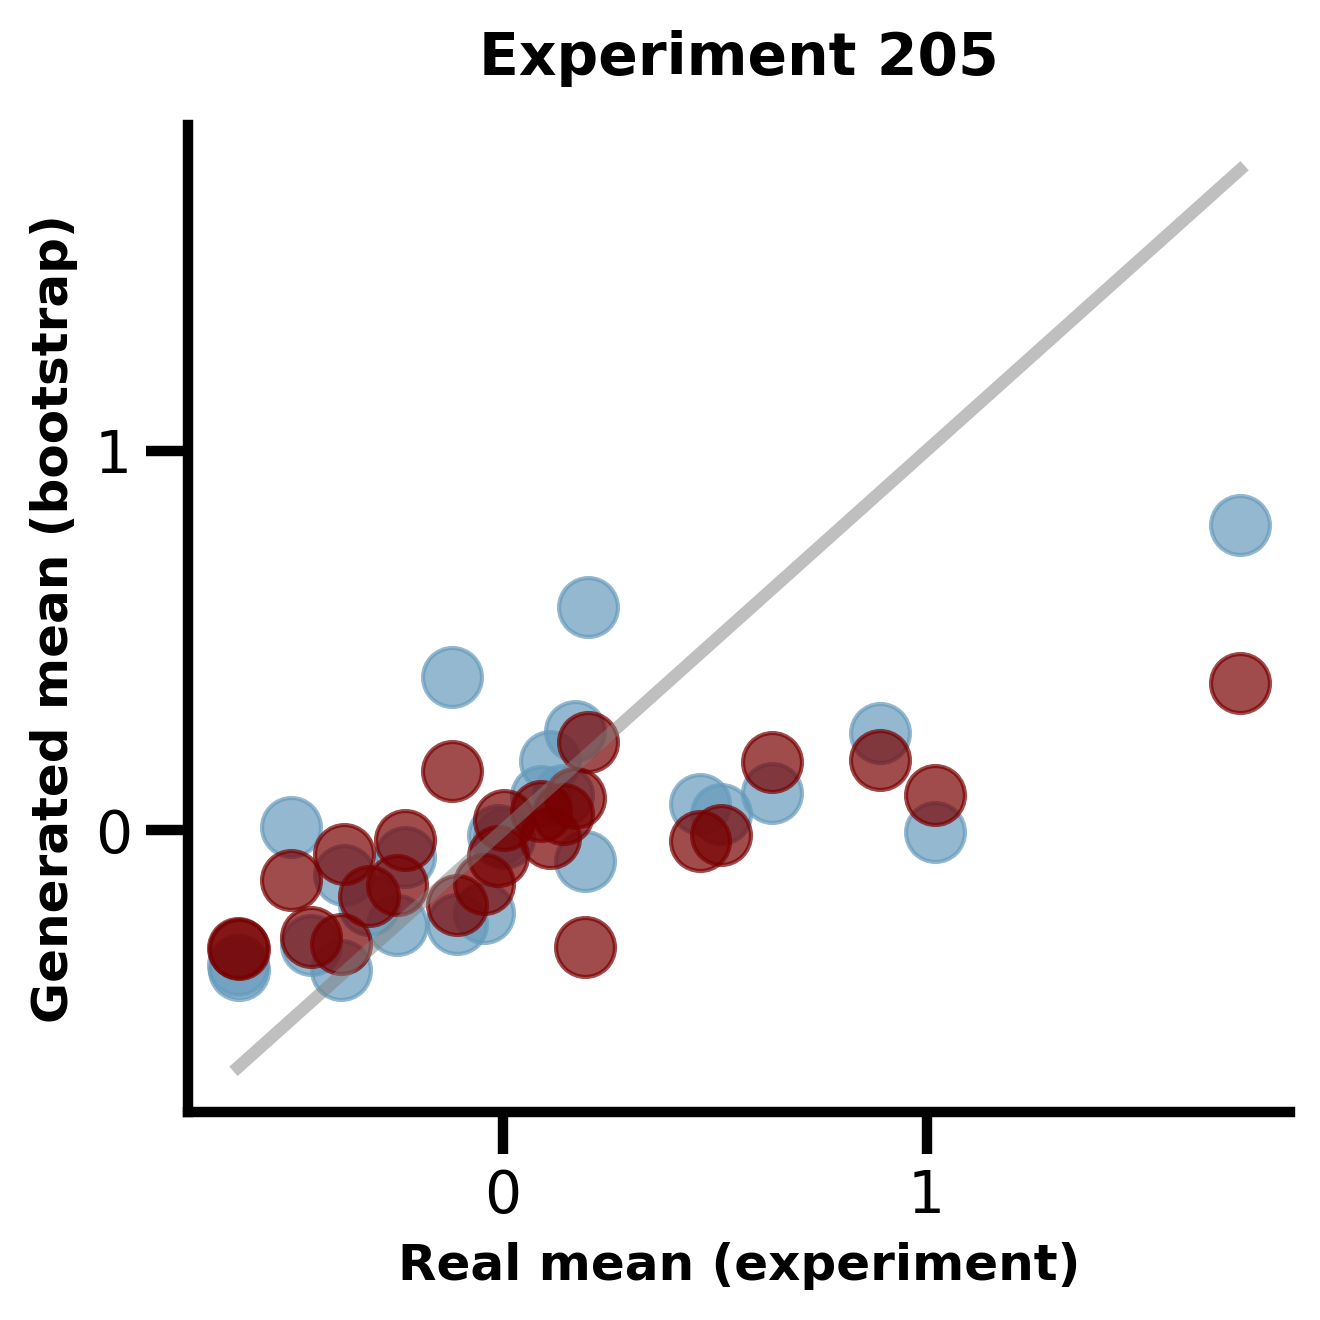

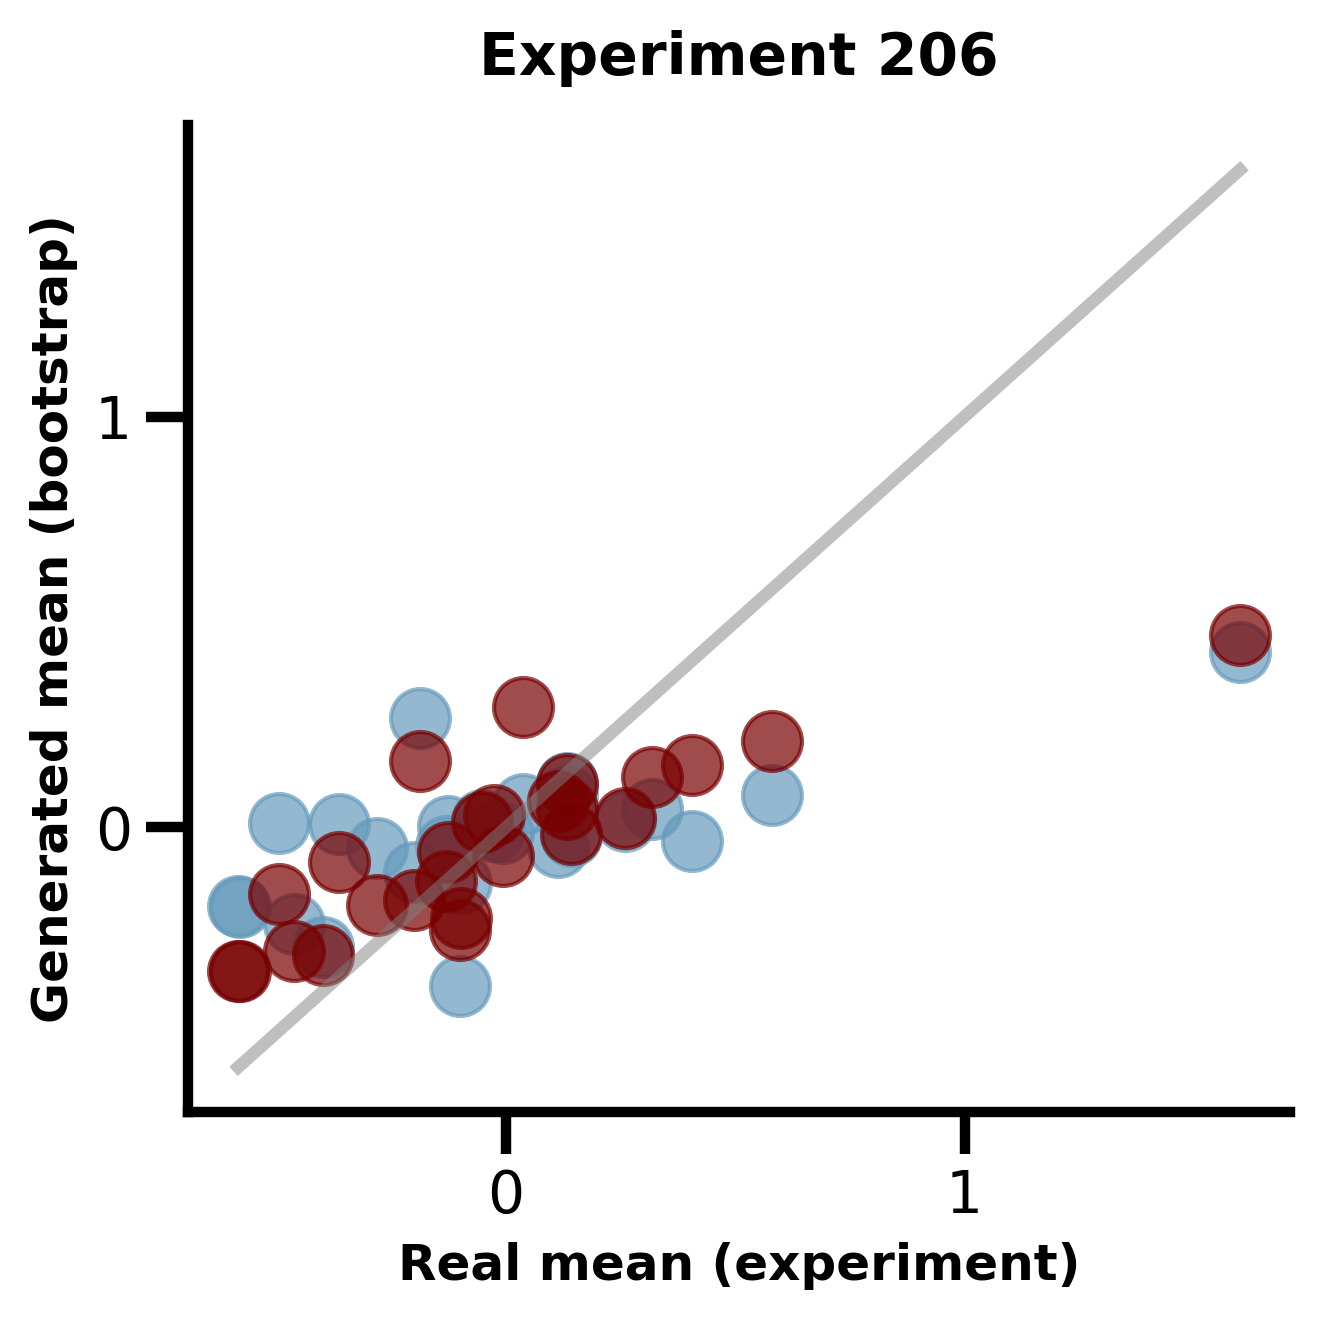

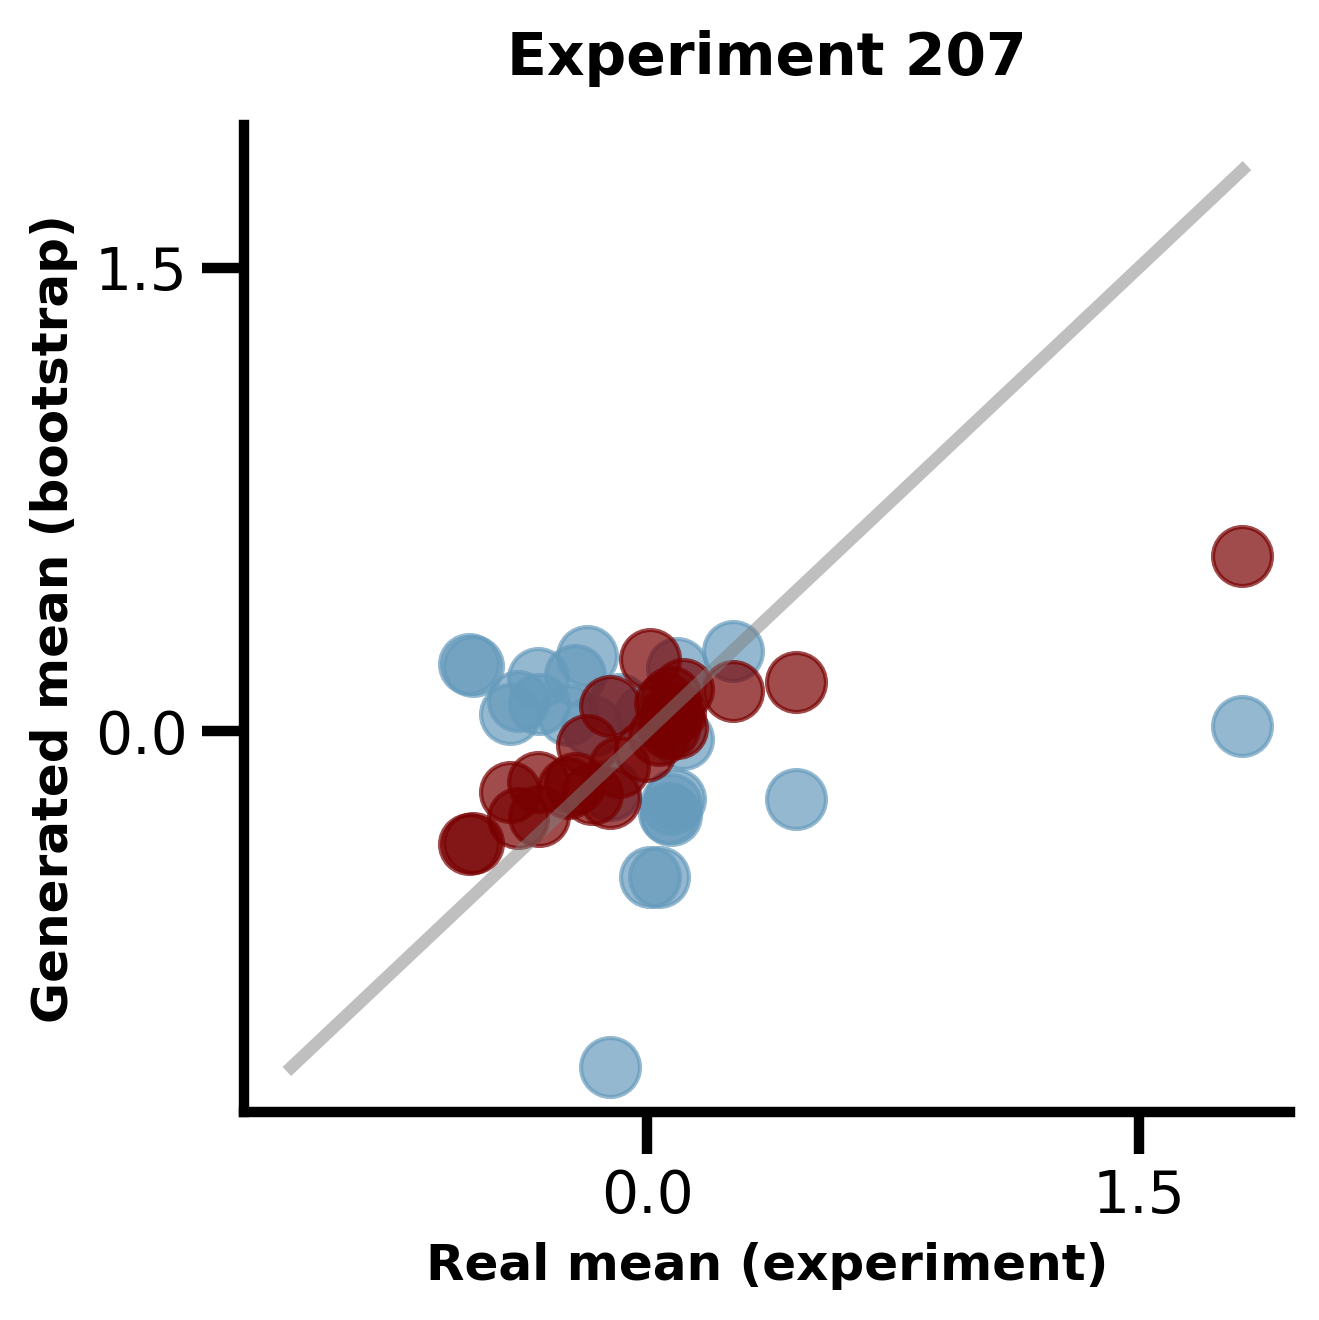

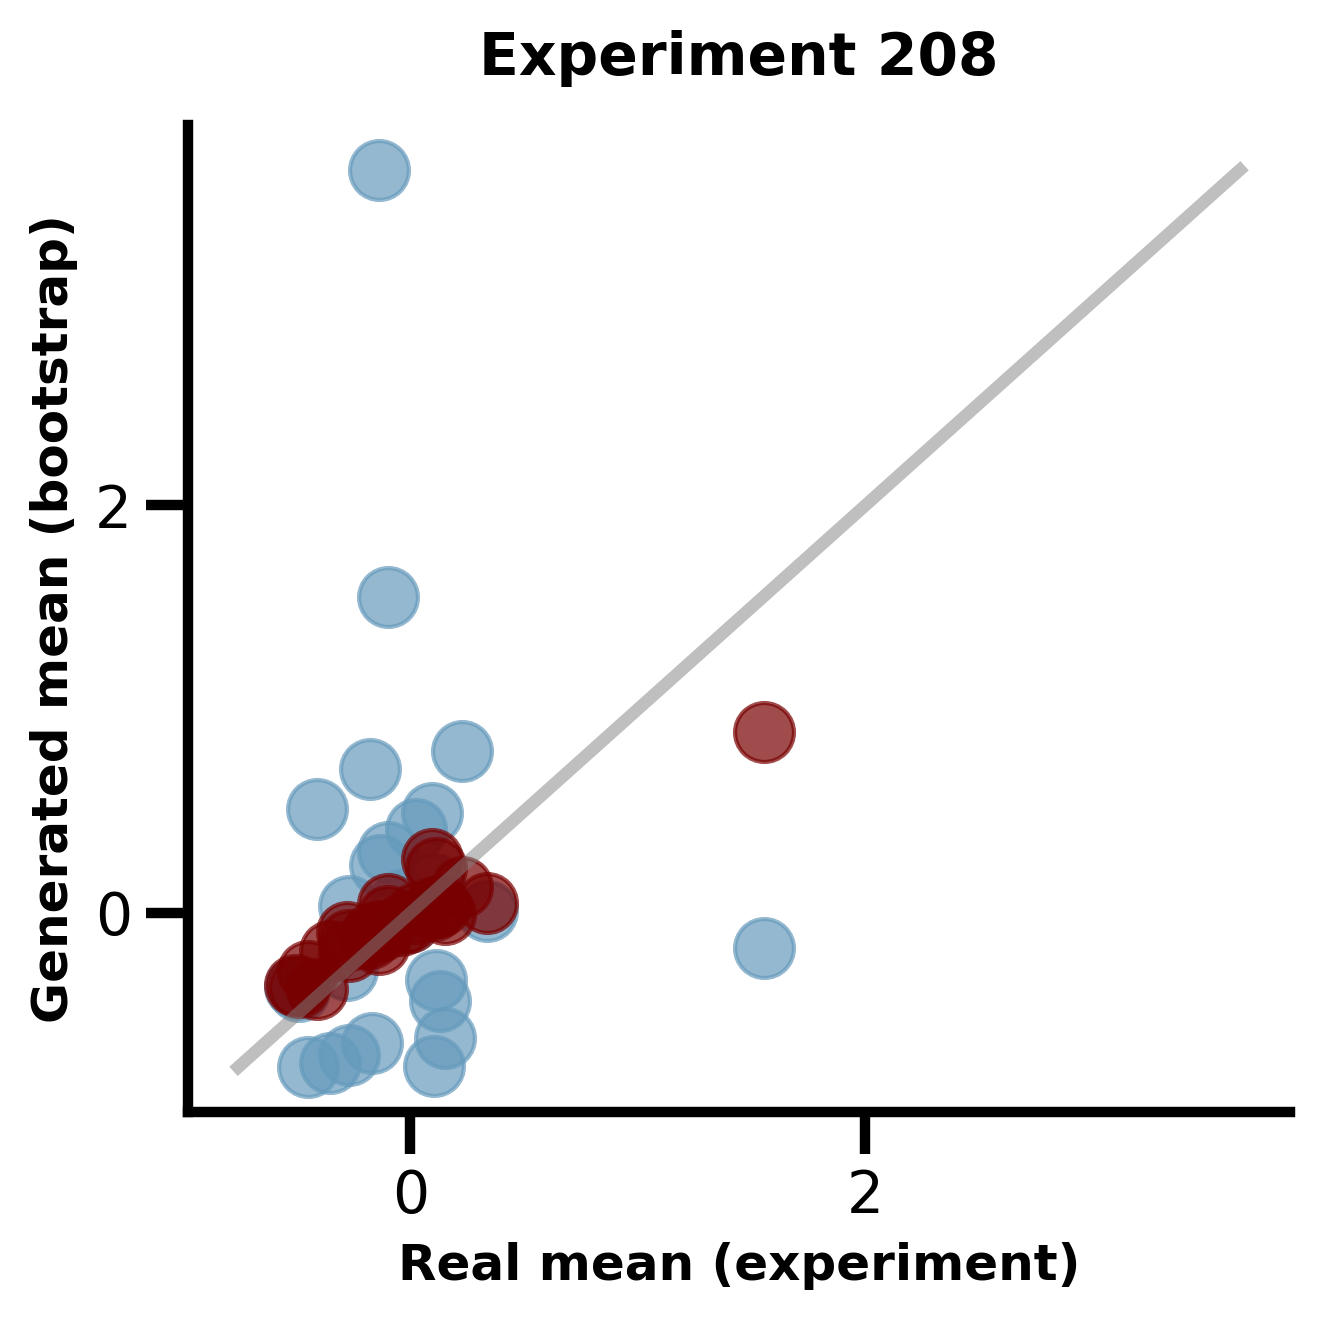

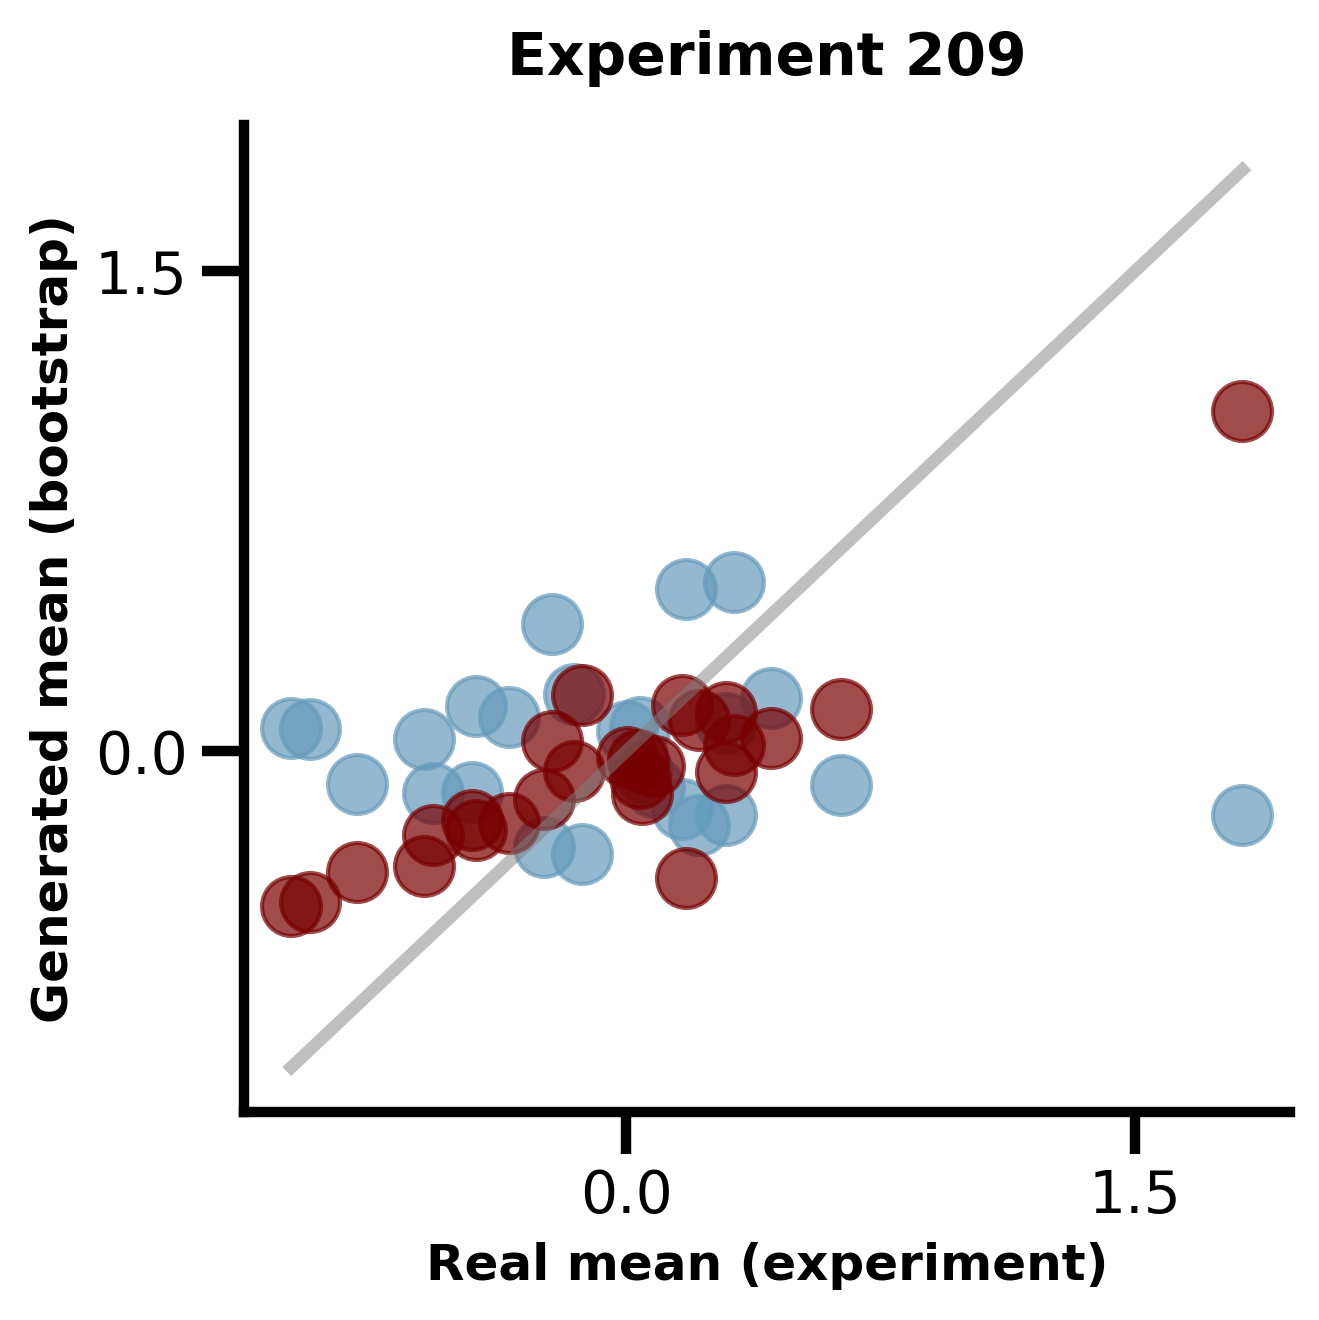

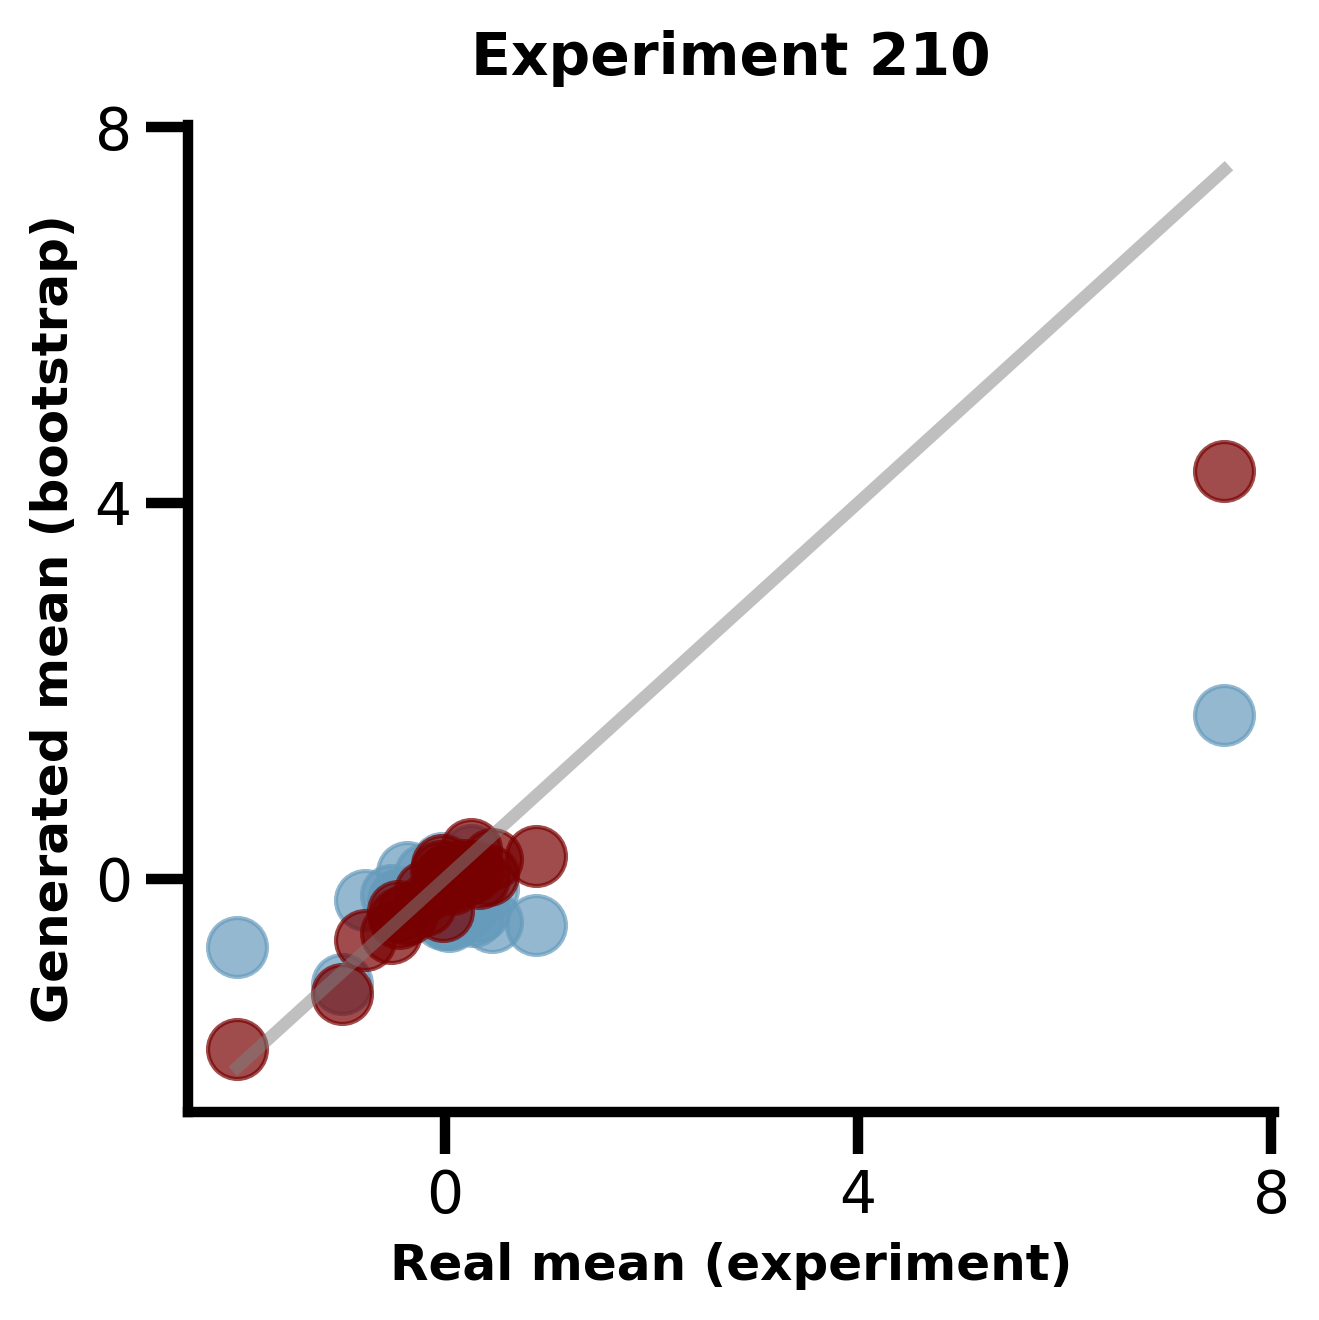

In [ ]:

# Colors
color_loop0 = '#669bbc'   # light blue
color_loop1 = '#780000'   # dark red

# ---- Iterate over every experiment ----
for exp_number, stats_df in stats_df_dict.items():

    # ---- Prepare data ----
    x  = stats_df["Mean Real"].values
    y0 = stats_df["Mean Loop 0"].values
    y1 = stats_df["Mean Loop 1"].values
    e0 = stats_df["Std Loop 0"].values
    e1 = stats_df["Std Loop 1"].values

    # ---- Smaller figure (4.5 x 4.5 inches) ----
    plt.figure(figsize=(4.5, 4.5), dpi=300)

    # Bigger dots (markersize=10, thicker caps)
    # plt.errorbar(x, y0,# yerr=e0,
    plt.scatter(x, y0,# yerr=e0,
                #  fmt='o', 
                 color=color_loop0, alpha=0.7,
                #  markersize=17, 
                #  capsize=4, capthick=1.5,
                #  linestyle='None', markeredgewidth=0,
                s=200,

                 label='_nolegend_')

    # plt.errorbar(x, y1,# yerr=e1,
    plt.scatter(x, y1,# yerr=e1,
                #  fmt='o',
                  color=color_loop1, alpha=0.7,
                #  markersize=17, 
                #  capsize=4, capthick=1.5,
                #  linestyle='None', markeredgewidth=0,
                s=200,
                 label='_nolegend_')

    # Diagonal reference line
    all_vals = np.concatenate([x, y0, y1])
    min_val, max_val = all_vals.min(), all_vals.max()
    # plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1, alpha=0.5,
    plt.plot([min_val, max_val], [min_val, max_val], linewidth=3, alpha=0.5,
             label='_nolegend_',color="gray")

    # ---- Labels and title (slightly smaller to fit the figure) ----
    plt.xlabel('Real mean (experiment)', fontsize=12, fontweight='bold')
    plt.ylabel('Generated mean (bootstrap)', fontsize=12, fontweight='bold')
    plt.title(f'Experiment {exp_number}', fontsize=14, fontweight='bold', pad=12)

    # ---- AXIS & TICK STYLING (three ticks, bigger and bolder) ----
    ax = plt.gca()

    # Thicker spines
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)

    # Exactly 3 ticks on each axis
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=3))

    # Bigger, bolder tick marks and labels
    ax.tick_params(axis='both', which='major',
                   labelsize=14,        # larger numbers
                   length=10,           # longer tick lines
                   width=2.5,           # thicker tick lines
                   color='black')

    # Subtle grid for a polished look
    # ax.grid(True, linestyle=':', linewidth=0.5, alpha=0.4, color='gray')
    ax.set_axisbelow(True)  # grid behind data

    # No legend
    legend = plt.legend()
    if legend:
        legend.remove()

    sns.despine()
    plt.tight_layout()

    # ---- Save and close ----
    plt.savefig(f'output/scatter_real_vs_generated_exp{exp_number}.png',
                bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()


### Evaluate Predictions.

In [54]:
# retrieve mean cell types and define store for results
ct_probs_loop0 = sim_data_loop0["ct_probs"]
ct_probs_loop1 = sim_data_loop1["ct_probs"]
mean_ct_probs_loop0 = ct_probs_loop0.mean(0)
mean_ct_probs_loop1 = ct_probs_loop1.mean(0)
exp_ct_props = {}

# iterate over the experiments
for idx, (exp_number, exp_idx) in enumerate(adata_lph012.obs.groupby("experiment_number").groups.items()):
    adata_exp = adata_lph012[exp_idx]

    # retrieve mean ct prob for each experiment
    gen_ct_probs_loop0 = mean_ct_probs_loop0[idx]
    gen_ct_probs_loop1 = mean_ct_probs_loop1[idx]
    real_ct_counts = le_ct.transform(adata_exp.obs["cell_type"])
    
    # compute ground truth cell type proportion on real data
    real_ct_probs = np.zeros_like(gen_ct_probs_loop0)
    for idx in range(len(real_ct_probs)):
        mask = np.argwhere(real_ct_counts == idx)
        real_ct_probs[idx] = len(mask) / len(real_ct_counts)

    # update store
    exp_ct_props[exp_number] = {
        "gen_loop0": gen_ct_probs_loop0,
        "gen_loop1": gen_ct_probs_loop1,
        "real": real_ct_probs,
    }

## Distance analysis.

### Condition space distance.

In [57]:
C_cond = cdist(X_cond_lpho012_log1p, X_cond_loop0_log1p)
C_cond_lpho012_nn_dist = C_cond.min(1)
C_cond.shape


(6, 116)

In [62]:
C_cond_lpho012_nn_dist

array([0.06899287, 0.69524823, 1.58102037, 4.61030115, 5.19661221,
       0.38299225])

### Phenotypic space distance.

In [58]:
# phenotype space distance
def get_distance_matrix(metric, X, Y):
    """
    Compute KL divergence from each row in X to each row in centers.
    X: shape (N, D)
    centers: shape (K, D)
    Returns: shape (N, K)
    """
    eps = 1e-12
    X = np.clip(X, eps, 1)[:, None, :]
    Y = np.clip(Y, eps, 1)[None, :, :]
    if metric == "jensen-shannon":
        return np.sqrt(0.5*np.sum(X*np.log(2*X / (Y + X)), axis=-1) + 0.5*np.sum(Y*np.log(2*Y / (Y + X)), axis=-1))
    elif metric == "jeffrey":
        return 0.5*np.sum(X* np.log(X / Y), axis=-1) + 0.5*np.sum(Y* np.log(Y/ X), axis=-1)
    elif metric == "kl-div":
        return np.sum(X * np.log(X / Y), axis=-1) # WARNING: not a metric
    else:
        raise ValueError
js_dist = lambda x, y: get_distance_matrix("jensen-shannon", x, y)

### Construct array of ground truth proportions.

In [59]:
# iterate over the experiments
gt_props = []
for idx, (exp_number, exp_idx) in enumerate(adata_lph012.obs.groupby("experiment_number").groups.items()):
    adata_exp = adata_lph012[exp_idx]
    # compute ground truth cell type proportion on real data
    real_ct_probs = np.zeros_like(gen_ct_probs_loop1)
    for idx in range(len(real_ct_probs)):
        mask = np.argwhere(real_ct_counts == idx)
        real_ct_probs[idx] = len(mask) / len(real_ct_counts)
    gt_props.append(real_ct_probs)
gt_props = np.stack(gt_props, axis=0)
gt_props.shape

(6, 24)

### Compute distances.

In [60]:
n_exp = gt_props.shape[0]
idxs = np.arange(n_exp)

C_js_loop0 = js_dist(mean_ct_probs_loop0, gt_props)[idxs, idxs]
C_js_loop1 = js_dist(mean_ct_probs_loop1, gt_props)[idxs, idxs]

print(f"{C_js_loop0=}, {C_js_loop1=}")


C_js_loop0=array([0.6281126 , 0.6182788 , 0.64058864, 0.7706279 , 0.7006874 ,
       0.4962098 ], dtype=float32), C_js_loop1=array([0.6114308 , 0.6132682 , 0.6088636 , 0.610199  , 0.5958096 ,
       0.16017702], dtype=float32)


### Visualize Distances.

/tmp/ipykernel_792529/2492011296.py:46: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax0.set_xlim(xlim0[0] - 0.05*(xlim0[1]-xlim0[0]),
/tmp/ipykernel_792529/2492011296.py:73: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax1.set_xlim(xlim1[0] - 0.05*(xlim1[1]-xlim1[0]),


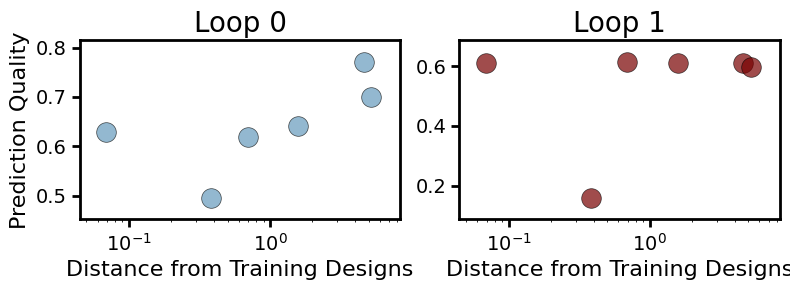

In [94]:
# ------------------------------------------------------------
# Replace these with your actual data for loop 0 and loop 1
# ------------------------------------------------------------
# Loop 0 data
x0 = C_cond_lpho012_nn_dist           # condition distances (log scale)
y0 = C_js_loop0                 # phenotypic distances
labels0 = lph012_exp_numbers   # annotation labels

# Loop 1 data – ADJUST NAMES TO YOUR VARIABLES
x1 = C_cond_lpho012_nn_dist      # e.g., condition distances for loop 1
y1 = C_js_loop1                 # e.g., phenotypic distances for loop 1
labels1 = lph012_exp_numbers  # or maybe same labels?

# Colors from your palette
blue_light = '#669bbc'   # light blue for loop 0
red_dark   = '#780000'   # dark red for loop 1

# ------------------------------------------------------------
# Create figure with two subplots side by side
# ------------------------------------------------------------
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(8, 3), sharey=False)

# ---------------- Left subplot: Loop 0 ----------------
ax0.scatter(x0, y0,
            alpha=0.7, edgecolors='k', linewidth=0.5, s=200,
            color=blue_light)

ax0.set_xscale("log")
ax0.set_xlabel(r"Distance from Training Designs", fontsize=16)
ax0.set_ylabel("Prediction Quality", fontsize=16)
ax0.set_title("Loop 0", fontsize=20)

# Annotations
# for x, y, label in zip(x0, y0, labels0):
#     ax0.annotate(str(label), (x, y),
#                  textcoords="offset points", xytext=(5, 5),
#                  fontsize=8, alpha=0.8,
#                  bbox=dict(boxstyle="round,pad=0.2",
#                            facecolor="white", alpha=0.6),
#                  clip_on=False)

# Add margins and axis limits (like your original)
ax0.margins(x=0.1, y=0.1)
xlim0 = ax0.get_xlim()
ylim0 = ax0.get_ylim()
ax0.set_xlim(xlim0[0] - 0.05*(xlim0[1]-xlim0[0]),
             xlim0[1] + 0.05*(xlim0[1]-xlim0[0]))
ax0.set_ylim(ylim0[0] - 0.05*(ylim0[1]-ylim0[0]),
             ylim0[1] + 0.05*(ylim0[1]-ylim0[0]))

# ---------------- Right subplot: Loop 1 ----------------
ax1.scatter(x1, y1,
            alpha=0.7, edgecolors='k', linewidth=0.5, s=200,
            color=red_dark)

ax1.set_xscale("log")
ax1.set_xlabel(r"Distance from Training Designs", fontsize=16)
ax1.set_ylabel("")          # optional: hide y-label to avoid duplication
ax1.set_title("Loop 1", fontsize=20)

# Annotations
# for x, y, label in zip(x1, y1, labels1):
#     ax1.annotate(str(label), (x, y),
#                  textcoords="offset points", xytext=(5, 5),
#                  fontsize=8, alpha=0.8,
#                  bbox=dict(boxstyle="round,pad=0.2",
#                            facecolor="white", alpha=0.6),
#                  clip_on=False)

ax1.margins(x=0.1, y=0.1)
xlim1 = ax1.get_xlim()
ylim1 = ax1.get_ylim()
ax1.set_xlim(xlim1[0] - 0.05*(xlim1[1]-xlim1[0]),
             xlim1[1] + 0.05*(xlim1[1]-xlim1[0]))
ax1.set_ylim(ylim1[0] - 0.05*(ylim1[1]-ylim1[0]),
             ylim1[1] + 0.05*(ylim1[1]-ylim1[0]))

# After creating ax0, ax1 ...
for ax in (ax0, ax1):
    ax.tick_params(axis='both', which='major',
                   labelsize=14,        # increase tick label font size
                   width=2,             # make tick lines thicker
                   length=6)            # make tick marks longer (optional)
    # Also thicken the axis spines (the box lines) if needed:
    for spine in ax.spines.values():
        spine.set_linewidth(2)

# Adjust layout so everything fits without overlapping
plt.tight_layout()
plt.savefig("output/refined_quality_vs_dist.png", dpi=300)
plt.savefig("output/refined_quality_vs_dist.svg", dpi=300)
plt.show()



## Compute uncertainties.

### Prepare populations.

In [64]:
n_pops = 10
n_iters = 100
uq_data_per_cond = {}
for idx, exp_number in enumerate(lph012_exp_numbers):
    # ---- Prepare populations for loop 0 ----
    pred_ct_probs_loop0 = ct_probs_loop0[:, idx]
    populations_loop0 = get_shuffled_populations(pred_ct_probs_loop0, n_pops=n_pops, n_iters=n_iters)

    # ---- Prepare populations for loop 1 ----
    pred_ct_probs_loop1 = ct_probs_loop1[:, idx]
    populations_loop1 = get_shuffled_populations(pred_ct_probs_loop1, n_pops=n_pops, n_iters=n_iters)

    # ---- Store data ----
    uq_data_per_cond[exp_number] = {
        "Loop 0": populations_loop0,
        "Loop 1": populations_loop1
    }

### Compute mean and variance.

In [65]:
uq_mean_std_mean = {}
uq_std_std_mean = {}
for exp_number, populations_dict in uq_data_per_cond.items():
    # ---- Get populations ----
    loop0_pop =  populations_dict["Loop 0"]
    loop1_pop =  populations_dict["Loop 1"]

    # ---- Loop 0 ----
    mean_probs_loop0 = loop0_pop.mean(-2)
    std_mean_probs_loop0 = mean_probs_loop0.std(-2)
    shuffled_mean_std_mean_probs_loop0 = std_mean_probs_loop0.mean(0)
    shuffled_std_std_mean_probs_loop0 = std_mean_probs_loop0.std(0)

    # ---- Loop 1 ----
    mean_probs_loop1 = loop1_pop.mean(-2)
    std_mean_probs_loop1 = mean_probs_loop1.std(-2)
    shuffled_mean_std_mean_probs_loop1 = std_mean_probs_loop1.mean(0)
    shuffled_std_std_mean_probs_loop1 = std_mean_probs_loop1.std(0)

    # ---- Store results ----
    uq_mean_std_mean[exp_number] = {
        "Loop 0": shuffled_mean_std_mean_probs_loop0,
        "Loop 1": shuffled_mean_std_mean_probs_loop1,
    }
    uq_std_std_mean[exp_number] = {
        "Loop 0": shuffled_std_std_mean_probs_loop0,
        "Loop 1": shuffled_std_std_mean_probs_loop1,
    }


### Compute cell type resolved reduction.

In [71]:
for exp_num, uq_dict in uq_mean_std_mean.items():
    loop0_uq = uq_dict["Loop 0"]
    loop1_uq = uq_dict["Loop 1"]
    print(f"{loop0_uq.shape=}, {loop1_uq.shape=}")


loop0_uq.shape=(24,), loop1_uq.shape=(24,)
loop0_uq.shape=(24,), loop1_uq.shape=(24,)
loop0_uq.shape=(24,), loop1_uq.shape=(24,)
loop0_uq.shape=(24,), loop1_uq.shape=(24,)
loop0_uq.shape=(24,), loop1_uq.shape=(24,)
loop0_uq.shape=(24,), loop1_uq.shape=(24,)


### Get reduction in uncertainty.

In [72]:
exp_order = lph012_exp_numbers          # e.g. ['exp1', 'exp2', ...]
x = C_cond_lpho012_nn_dist             # log‑scale condition distances

# Collect per‑cell‑type uncertainties
unc_loop0 = np.array([uq_mean_std_mean[exp]["Loop 0"] for exp in exp_order])   # (n_exps, 24)
unc_loop1 = np.array([uq_mean_std_mean[exp]["Loop 1"] for exp in exp_order])   # (n_exps, 24)

# Reduction (positive = uncertainty decreased)
reduction_per_ct = unc_loop0 - unc_loop1                     # (n_exps, 24)

# Aggregate (mean over cell types)
reduction_mean = reduction_per_ct.mean(axis=1)               # (n_exps,)

### Plot uncertainty reduction (cell type resolved).

Cell types order: ['CD14Mono', 'CD16Mono', 'CyclingPro1', 'CyclingPro2', 'Early_GMP', 'EosBasMast1', 'EosBasMast2', 'EosBasMast3', 'EryPro', 'GMP-Neutro', 'GMP_cycling', 'HSCs', 'LMPP-CLP', 'MLP', 'MPP', 'MPP_MgkEry', 'MgKEryPro1', 'MgKEryPro2', 'ProB', 'earlyMPP', 'late_MgkPro', 'preProB', 'pre_cDC1', 'pre_cDC2']
Number of cell types: 24


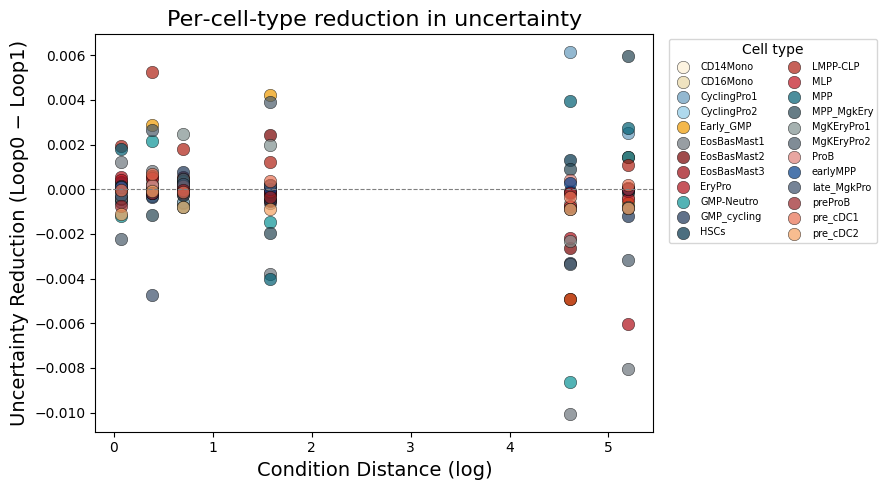

In [85]:
# You already ran this:
cell_type_names = list(le_ct.classes_)          # this should be length 24
n_cell_types = len(cell_type_names)
print("Cell types order:", cell_type_names)
print("Number of cell types:", n_cell_types)

# Remove duplicate key if present
if 'late_MgkPro' in color_map:
    # If you need only one, keep the last one; adjust as you wish
    pass  # already a single value after the duplicate lines above – you only need one entry

# Create an ordered list of colors matching cell_type_names
colors = [color_map[name] for name in cell_type_names]

# Data (same as before)
exp_order = lph012_exp_numbers
x = C_cond_lpho012_nn_dist
unc_loop0 = np.array([uq_mean_std_mean[exp]["Loop 0"] for exp in exp_order])
unc_loop1 = np.array([uq_mean_std_mean[exp]["Loop 1"] for exp in exp_order])
reduction_per_ct = unc_loop0 - unc_loop1   # (n_exps, n_cell_types)

fig, ax = plt.subplots(figsize=(9, 5))

for ct in range(n_cell_types):
    ax.scatter(x, reduction_per_ct[:, ct],
               label=cell_type_names[ct],
               color=colors[ct],
               alpha=0.7, edgecolors='k', linewidth=0.4, s=80)

# ax.set_xscale("log")
ax.set_xlabel("Condition Distance (log)", fontsize=14)
ax.set_ylabel("Uncertainty Reduction (Loop0 − Loop1)", fontsize=14)
ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
ax.legend(title="Cell type", bbox_to_anchor=(1.02, 1), loc='upper left',
          fontsize=7, ncol=2)   # ncol=2 for 24 entries
ax.set_title("Per‑cell‑type reduction in uncertainty", fontsize=16)
plt.tight_layout()
plt.show()

### Aggregate uncertainty per cell type.

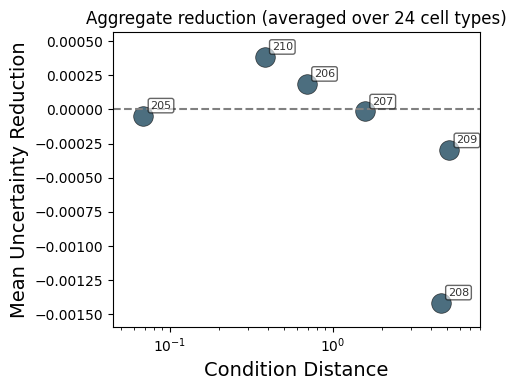

In [84]:
reduction_mean = reduction_per_ct.mean(axis=1)

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(x, reduction_mean, alpha=0.7, edgecolors='k', linewidth=0.5,
           s=200, color='#003049')
ax.set_xscale("log")
ax.set_xlabel("Condition Distance", fontsize=14)
ax.set_ylabel("Mean Uncertainty Reduction", fontsize=14)
ax.axhline(0, color='grey', linestyle='--')
ax.set_title("Aggregate reduction (averaged over 24 cell types)")

# Annotate with experiment labels
for xi, yi, lbl in zip(x, reduction_mean, exp_order):
    ax.annotate(str(lbl), (xi, yi),
                textcoords="offset points", xytext=(5, 5),
                fontsize=8, alpha=0.8,
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.6))

ax.margins(x=0.1, y=0.1)
plt.tight_layout()
plt.show()

## Plot UMAP of MgkPro.

### Add field for MgkPro cells from new experiments.

In [107]:
# ---- Compute masks ----
lpho012_mask = adata_loop1_500k.obs.experiment_number.map(lambda e: e in lph012_exp_numbers)
mgkpro_mask = adata_loop1_500k.obs.cell_type == "late_MgkPro"
new_mgkpro_mask = lpho012_mask &  mgkpro_mask
old_mgkpro_mask = ~lpho012_mask &  mgkpro_mask

# ---- Compute masks ----
n_mgkpro = mgkpro_mask.sum() 
n_new_mgkpro = new_mgkpro_mask.sum() 
n_old_mgkpro = old_mgkpro_mask.sum()

# ---- Add new Field ---
is_mgkpro_val = np.full(lpho012_mask.shape, "Other cell-type", dtype=object)
is_mgkpro_val[new_mgkpro_mask] = "MgkPro Loop 1"
is_mgkpro_val[old_mgkpro_mask] = "MgkPro Loop 0"
adata_loop1_500k.obs["MgkPro Source"] = is_mgkpro_val


### Plot UMAPS.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ------------------ Colour map & groups -------------------
color_map = {
    "MgkPro Loop 0": "#669bbc",
    "MgkPro Loop 1": "#780000",
    "Other cell-type": "#380000",
}
groups = ["MgkPro Loop 0", "MgkPro Loop 1"]   # only these are plotted

# ------------------ 1. Main plot – no legend --------------
fig = sc.pl.embedding(
    adata_loop1_500k,
    basis="umap",
    color="MgkPro Source",
    groups=groups,
    palette=color_map,
    s=20,
    frameon=False,
    legend_loc='none',    # <-- kills the legend
    return_fig=True,
    show=False
)

fig.savefig("output/umap_plot.png", dpi=300, bbox_inches="tight")
fig.savefig("output/umap_plot.svg", bbox_inches="tight")
plt.close(fig)

# ------------------ 2. Standalone legend -------------------
# Create a patch (coloured square) for each group you want in the legend
legend_patches = [mpatches.Patch(color=color_map[grp], label=grp)
                  for grp in groups]   # only the two plotted groups

# If you also want to include "Other cell-type", add it:
# legend_patches.append(mpatches.Patch(color=color_map["Other cell-type"], label="Other cell-type"))

fig_leg, ax_leg = plt.subplots(figsize=(2.0, 1.5))
ax_leg.legend(handles=legend_patches,
              loc='center',
              frameon=False,
              fontsize=12)
ax_leg.axis('off')

fig_leg.savefig("output/legend.png", dpi=300, bbox_inches="tight")
fig_leg.savefig("output/legend.svg", bbox_inches="tight")
plt.close(fig_leg)
